##Loading dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bangladeshi_taka.zip to bangladeshi_taka.zip


In [ ]:
import zipfile

zip_path = "bangladeshi_taka.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

##1. Total image per class

In [ ]:
import os

label_path = "train/labels"

class_counts = {}

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), 'r') as f:
        for line in f.readlines():
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

print(class_counts)

{3: 120, 7: 105, 1: 126, 6: 99, 8: 90, 2: 147, 4: 120, 0: 132, 5: 108}


In [ ]:
names = ['10 tk','100 tk','1000 tk','2 tk','20 tk','200 tk','5 tk','50 tk','500 tk']

for k, v in class_counts.items():
    print(names[k], ":", v)

2 tk : 120
50 tk : 105
100 tk : 126
5 tk : 99
500 tk : 90
1000 tk : 147
20 tk : 120
10 tk : 132
200 tk : 108


##Showing images from each class

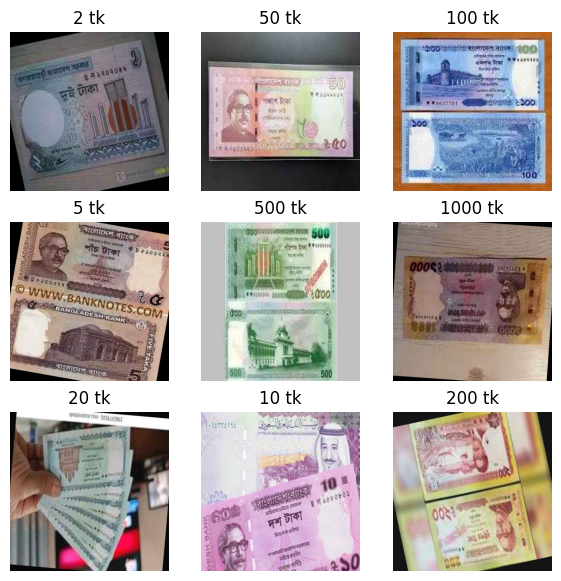

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "train/images"
label_dir = "train/labels"

names = ['10 tk','100 tk','1000 tk','2 tk','20 tk','200 tk','5 tk','50 tk','500 tk']

selected = {}

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file)) as f:
        cls = int(f.readline().split()[0])
        if cls not in selected:
            img_name = file.replace(".txt", ".jpg")
            selected[cls] = img_name

    if len(selected) == 9:
        break


plt.figure(figsize=(7,7))

for i, (cls, img_name) in enumerate(selected.items()):
    img = cv2.imread(os.path.join(image_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(names[cls])
    plt.axis('off')

plt.show()

##2. Data Annotation & Dataset Preparation

###Installing Ultralytics and loading model

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00


###Datset stucture

In [ ]:
'''dataset/
 ├── train/
 │    ├── images/
 │    └── labels/
 │
 ├── valid/
 │    ├── images/
 │    └── labels/
 │
 ├── test/
 │    ├── images/
 │    └── labels/
 │
 └── data.yaml '''

'dataset/\n ├── train/\n │    ├── images/\n │    └── labels/\n │\n ├── valid/\n │    ├── images/\n │    └── labels/\n │\n ├── test/\n │    ├── images/\n │    └── labels/\n │\n └── data.yaml '

The dataset is organized in YOLO format with separate folders for training, validation, and testing. Each subset contains corresponding images and label files. The data.yaml file defines class names and dataset paths.

In [ ]:
#Showing folder structure
import os

for root, dirs, files in os.walk("train"):
    print(root, "->", len(files), "files")

train -> 0 files
train/images -> 717 files
train/labels -> 717 files


In [ ]:
#Check sample label file
label_file = os.listdir("train/labels")[0]

with open("train/labels/" + label_file) as f:
    print(f.read())

3 0.48828125 0.50390625 0.9765625 0.87109375


In [ ]:
#veifying data.yaml
with open("data.yaml") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 9
names: ['10 tk', '100 tk', '1000 tk', '2 tk', '20 tk', '200 tk', '5 tk', '50 tk', '500 tk']

roboflow:
  workspace: kanks-workspace
  project: bdt_taka
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/kanks-workspace/bdt_taka/dataset/1


As we can see the dataset contains 9 classes representing different Bangladeshi Taka denominations. The dataset is already split into training, validation, and test sets, and annotations are provided in YOLO format.

##3. Model Training

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

model.train(
    data="data.yaml",
    epochs=40,
    imgsz=512
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d44c4bad20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

##4. Model Evaluation

In [ ]:
model.val()

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,591 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 686.9±252.1 MB/s, size: 31.9 KB)
val: Scanning /content/valid/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 4.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10, len(boxes) = 93. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5it/s 3.4s
                   all         68         93      0.929      0.842      0.948      0.883
                 10 tk          8          9      0.903      0.667      0.849       0.84
                100 tk          6         10      0.885   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d3b4cd29c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

The model was evaluated using the validation dataset. The overall mAP50 score is approximately 0.95. The model shows good detection performance across different classes, with most classes achieving high mAP values.

In [ ]:
model.predict(
    source="test/images",
    save=True
)


image 1/34 /content/test/images/10-taka-1-3-_jpg.rf.89ae19eaf9e9b64d6d2397f455feba6b.jpg: 512x512 1 10 tk, 34.7ms
image 2/34 /content/test/images/10-taka-3-3-_jpg.rf.3d1a758f01b9bc7266e10c67974f3793.jpg: 512x512 1 10 tk, 23.2ms
image 3/34 /content/test/images/10-taka-5-_jpg.rf.5cc7f6f63417872b2b6d43ea1a27a8da.jpg: 512x512 3 10 tks, 34.0ms
image 4/34 /content/test/images/100-taka-1-_jpg.rf.5866be7b577e0b13b9d2e794eaaa9684.jpg: 512x512 1 100 tk, 24.1ms
image 5/34 /content/test/images/100-taka-15-_jpg.rf.a587227a8e50a62bc3ac8c444ce2c038.jpg: 512x512 1 100 tk, 47.1ms
image 6/34 /content/test/images/100-taka-20-_jpg.rf.df5bba9fce9fcfc782ced7ed9d4cf163.jpg: 512x512 2 100 tks, 17.9ms
image 7/34 /content/test/images/100-taka-27-_jpg.rf.d9032dbeed89f9f8df4d9fec5c71489e.jpg: 512x512 1 100 tk, 42.0ms
image 8/34 /content/test/images/100-taka-9-_jpg.rf.0370b2c72b80975da56623438f537ceb.jpg: 512x512 2 100 tks, 20.9ms
image 9/34 /content/test/images/1000-taka-21-_jpg.rf.c9e79cb6793500a393f9197b564c21

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '10 tk', 1: '100 tk', 2: '1000 tk', 3: '2 tk', 4: '20 tk', 5: '200 tk', 6: '5 tk', 7: '50 tk', 8: '500 tk'}
 obb: None
 orig_img: array([[[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        [[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        [[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        ...,
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1],
         ...,
         [ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1]],
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1],
         ...,
 

###Displaying result

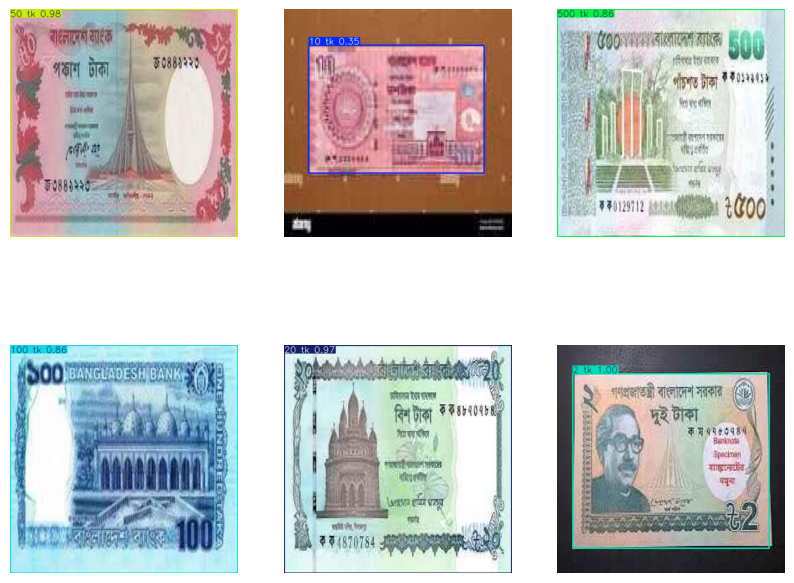

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

pred_path = "runs/detect/predict"

files = os.listdir(pred_path)[:6]

plt.figure(figsize=(10,8))

for i, file in enumerate(files):
    img = cv2.imread(os.path.join(pred_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

As we can see the trained model can able to predict bangaldeshi note images using bounding box where avg accuracy is 0.86 or more for all 9 classes. That means the model is trained really wellunder the given dataset.

##Bonus Task (Fine-tuning the existion model)

###Uploading model file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving best.pt to best.pt


###Loading model

In [ ]:
from ultralytics import YOLO
model = YOLO("best.pt")

###Uploading updated dataset(ZIP)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bdt_taka.v3i.yolo26.zip to bdt_taka.v3i.yolo26.zip


###Unziping updated dataset

In [ ]:
import zipfile

with zipfile.ZipFile("bdt_taka.v3i.yolo26.zip", 'r') as zip_ref:
    zip_ref.extractall()

###Verifying datset

In [ ]:
import os
os.listdir()

['.config',
 'bdt_taka.v3i.yolo26.zip',
 'README.roboflow.txt',
 'train',
 'drive',
 'test',
 'valid',
 'best.pt',
 'bangladeshi_taka.zip',
 'yolo26n.pt',
 'README.dataset.txt',
 'runs',
 'data.yaml',
 'sample_data']

###Total images per class

In [ ]:
import os

label_path = "train/labels"

class_counts = {}

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), 'r') as f:
        for line in f.readlines():
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

print(class_counts)

{0: 220, 8: 225, 7: 169, 9: 105, 4: 236, 3: 200, 1: 210, 10: 90, 6: 174, 2: 245, 5: 192}


###Showing images from each classes

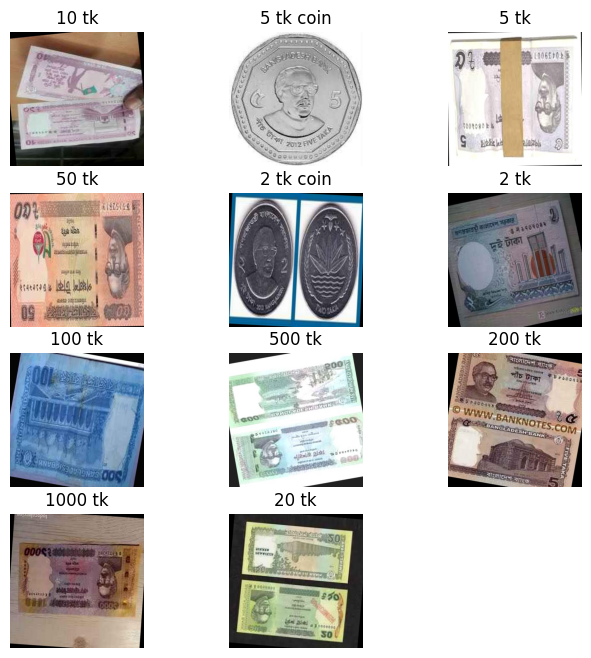

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "train/images"
label_dir = "train/labels"

names = ['10 tk', '100 tk', '1000 tk', '2 tk', '2 tk coin', '20 tk', '200 tk', '5 tk', '5 tk coin', '50 tk', '500 tk']

selected = {}

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file)) as f:
        cls = int(f.readline().split()[0])

        if cls not in selected:
            img_name = file.replace(".txt", ".jpg")
            selected[cls] = img_name

    if len(selected) == 11:
        break


plt.figure(figsize=(8,8))

for i, (cls, img_name) in enumerate(selected.items()):
    img = cv2.imread(os.path.join(image_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.title(names[cls])
    plt.axis('off')

plt.show()

###Training (fine-tuning)

In [ ]:
model.train(
    data="data.yaml",
    epochs=30,
    imgsz=512
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d450c6ba40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

###Evaluate

In [ ]:
model.val()

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1013.4±465.5 MB/s, size: 32.8 KB)
val: Scanning /content/valid/labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 33.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 40, len(boxes) = 123. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.5it/s 2.4s
                   all         87        123      0.858      0.835      0.915       0.86
                 10 tk          8          9      0.849      0.889      0.885       0.87
                100 tk          6         10      0.708

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d4691e2fc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

###Predicting

In [ ]:
model.predict(
    source="test/images",
    save=True
)


image 1/43 /content/test/images/10-taka-1-3-_jpg.rf.89ae19eaf9e9b64d6d2397f455feba6b.jpg: 512x512 1 10 tk, 9.2ms
image 2/43 /content/test/images/10-taka-3-3-_jpg.rf.3d1a758f01b9bc7266e10c67974f3793.jpg: 512x512 1 10 tk, 9.7ms
image 3/43 /content/test/images/10-taka-5-_jpg.rf.5cc7f6f63417872b2b6d43ea1a27a8da.jpg: 512x512 2 10 tks, 11.0ms
image 4/43 /content/test/images/100-taka-1-_jpg.rf.5866be7b577e0b13b9d2e794eaaa9684.jpg: 512x512 1 100 tk, 9.4ms
image 5/43 /content/test/images/100-taka-15-_jpg.rf.a587227a8e50a62bc3ac8c444ce2c038.jpg: 512x512 1 100 tk, 9.4ms
image 6/43 /content/test/images/100-taka-20-_jpg.rf.df5bba9fce9fcfc782ced7ed9d4cf163.jpg: 512x512 2 100 tks, 9.8ms
image 7/43 /content/test/images/100-taka-27-_jpg.rf.d9032dbeed89f9f8df4d9fec5c71489e.jpg: 512x512 1 100 tk, 11.4ms
image 8/43 /content/test/images/100-taka-9-_jpg.rf.0370b2c72b80975da56623438f537ceb.jpg: 512x512 2 100 tks, 9.4ms
image 9/43 /content/test/images/1000-taka-21-_jpg.rf.c9e79cb6793500a393f9197b564c21d4.jpg

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '10 tk', 1: '100 tk', 2: '1000 tk', 3: '2 tk', 4: '2 tk coin', 5: '20 tk', 6: '200 tk', 7: '5 tk', 8: '5 tk coin', 9: '50 tk', 10: '500 tk'}
 obb: None
 orig_img: array([[[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        [[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        [[18, 18, 18],
         [18, 18, 18],
         [18, 18, 18],
         ...,
         [28, 28, 28],
         [28, 28, 28],
         [28, 28, 28]],
 
        ...,
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1],
         ...,
         [ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1]],
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
     

###Displaying result for the updated model

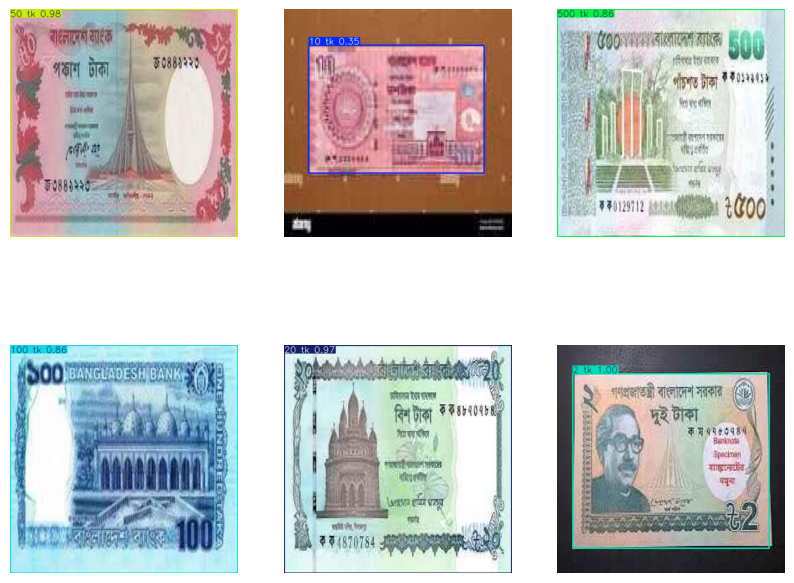

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

pred_path = "runs/detect/predict"
files = os.listdir(pred_path)[:6]
plt.figure(figsize=(10,8))

for i, file in enumerate(files):
    img = cv2.imread(os.path.join(pred_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

###After fine-tuning, the model is able to detect Bangladeshi coins along with Bangladeshi Taka notes. This indicates that the fine-tuning process was successful.

###Downloding the best.pt

In [ ]:
import os
os.listdir("runs/detect")

In [ ]:
from google.colab import files
files.download("runs/detect/train3/weights/best.pt")